## Check on lower dresscode

In [61]:
import torch
import torchvision
import matplotlib.pyplot as plt


In [85]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

def create_rgb_heatmap(attention_scores, height, width, save_path=None):
    """
    Generate RGB heatmap visualization from attention scores.
    
    Args:
        attention_scores: Tensor of shape (batch_size, num_heads, seq_len, seq_len)
        height: Height of the output heatmap
        width: Width of the output heatmap
        save_path: Optional path to save the visualization
    Returns:
        RGB heatmap as numpy array with shape (height, width, 3)
    """
    # Average attention scores across batch and heads
    # avg_attention = attention_scores.mean(dim=(0, 1))  # Shape: (seq_len, seq_len)
    avg_attention = attention_scores
    
    # Reshape to spatial dimensions
    attention_map = avg_attention.view(height, width, -1).cpu().numpy()
    
    # Normalize to [0, 1]
    attention_map = (attention_map - attention_map.min()) / (attention_map.max() - attention_map.min())
    
    # Create custom colormap (blue -> green -> red)
    colors = [(0, 0, 1), (0, 1, 0), (1, 0, 0)]  # RGB
    n_bins = 256
    cmap = LinearSegmentedColormap.from_list("custom", colors, N=n_bins)
    
    # Convert attention map to RGB
    rgb_heatmap = cmap(attention_map)[..., :3]  # Remove alpha channel
    
    if save_path:
        plt.figure(figsize=(10, 10))
        plt.imshow(rgb_heatmap)
        plt.colorbar()
        plt.axis('off')
        plt.savefig(save_path, bbox_inches='tight', pad_inches=0)
        plt.close()
    
    return rgb_heatmap

def visualize_attention_rgb(attention_scores, height, width, overlay_image=None, alpha=0.6, save_path=None):
    """
    Visualize attention scores as RGB heatmap, optionally overlaid on an image.
    
    Args:
        attention_scores: Tensor of shape (batch_size, num_heads, seq_len, seq_len)
        height: Height of the heatmap
        width: Width of the heatmap
        overlay_image: Optional PIL Image or numpy array to overlay heatmap on
        alpha: Transparency of heatmap when overlaying (0-1)
        save_path: Optional path to save visualization
    """
    rgb_heatmap = create_rgb_heatmap(attention_scores, height, width)
    
    if overlay_image is not None:
        # Convert overlay image to numpy if needed
        if not isinstance(overlay_image, np.ndarray):
            overlay_image = np.array(overlay_image)
        
        # Normalize overlay image
        overlay_image = overlay_image.astype(float) / 255
        
        # Blend heatmap with image
        blended = alpha * rgb_heatmap.squeeze(-2) + (1 - alpha) * overlay_image
        blended = np.clip(blended, 0, 1)
        
        plt.figure(figsize=(10, 10))
        plt.imshow(blended)
        plt.axis('off')
        
        if save_path:
            plt.savefig(save_path, bbox_inches='tight', pad_inches=0)
            plt.close()
        else:
            plt.show()
            plt.close()
    
    return rgb_heatmap

In [2]:
attention_map = torch.load("attention_map.pt")

In [3]:
attention_map.shape

torch.Size([2, 12288, 128, 96])

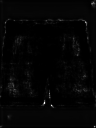

In [38]:
q_inx = 3918 # left leg location
x3 = (attention_map[1,q_inx,:,:])
attn_map_view_norm = (x3 - x3.min()) / (x3.max() - x3.min())
torchvision.transforms.ToPILImage()(attn_map_view_norm)

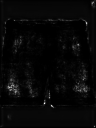

In [39]:
q_inx = 5262 # right leg location
x3 = (attention_map[1,q_inx,:,:])
attn_map_view_norm = (x3 - x3.min()) / (x3.max() - x3.min())
torchvision.transforms.ToPILImage()(attn_map_view_norm)

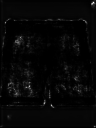

In [40]:
q_inx= 4584 # center of short
x3 = (attention_map[1,q_inx,:,:])
attn_map_view_norm = (x3 - x3.min()) / (x3.max() - x3.min())
torchvision.transforms.ToPILImage()(attn_map_view_norm)

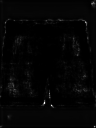

In [31]:
q_inx=3918
x3 = (attention_map[1,q_inx,:,:])
attn_map_view_norm = (x3 - x3.min()) / (x3.max() - x3.min())
torchvision.transforms.ToPILImage()(attn_map_view_norm)

# VTON HD

In [41]:
attention_map_hd = torch.load("attention_map_hd.pt")

In [42]:
attention_map_hd.shape

torch.Size([2, 12288, 128, 96])

In [91]:
overlay_image = Image.open("/workspace/Try-on-Product/projects/Leffa/01486_00.jpg").resize((96,128))

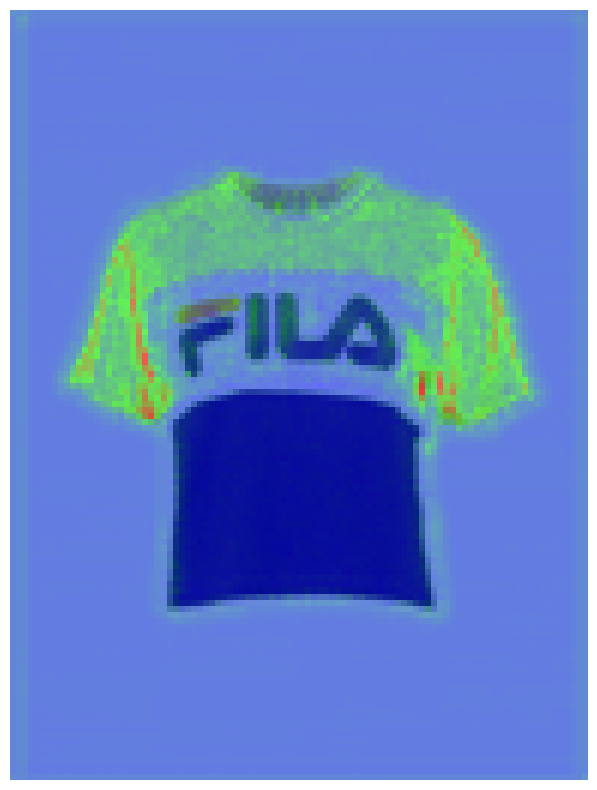

array([[[[0.        , 0.31372549, 0.68627451]],

        [[0.        , 0.2745098 , 0.7254902 ]],

        [[0.        , 0.32941176, 0.67058824]],

        ...,

        [[0.        , 0.26666667, 0.73333333]],

        [[0.        , 0.29019608, 0.70980392]],

        [[0.        , 0.25098039, 0.74901961]]],


       [[[0.        , 0.24313725, 0.75686275]],

        [[0.        , 0.35294118, 0.64705882]],

        [[0.        , 0.37647059, 0.62352941]],

        ...,

        [[0.        , 0.2745098 , 0.7254902 ]],

        [[0.        , 0.30588235, 0.69411765]],

        [[0.        , 0.29803922, 0.70196078]]],


       [[[0.        , 0.25098039, 0.74901961]],

        [[0.        , 0.32941176, 0.67058824]],

        [[0.        , 0.32156863, 0.67843137]],

        ...,

        [[0.        , 0.23529412, 0.76470588]],

        [[0.        , 0.26666667, 0.73333333]],

        [[0.        , 0.26666667, 0.73333333]]],


       ...,


       [[[0.        , 0.21960784, 0.78039216]],

       

In [92]:
q_inx = 4641 # righ showder
x3 = (attention_map_hd[1,q_inx,:,:])
attn_map_view_norm = (x3 - x3.min()) / (x3.max() - x3.min())
# torchvision.transforms.ToPILImage()(attn_map_view_norm)
# plt.imshow(attn_map_view_norm.cpu().numpy(), cmap='hot', interpolation='nearest')
# plt.show()
visualize_attention_rgb(x3,128,96,overlay_image=overlay_image, alpha=0.6, save_path=None)

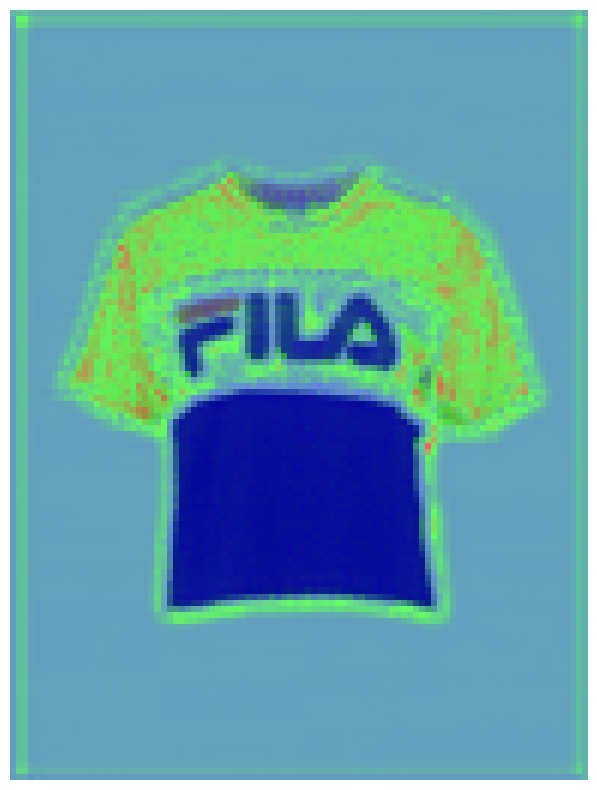

array([[[[0.        , 0.54901961, 0.45098039]],

        [[0.        , 0.61960784, 0.38039216]],

        [[0.        , 0.69803922, 0.30196078]],

        ...,

        [[0.        , 0.54901961, 0.45098039]],

        [[0.        , 0.64313725, 0.35686275]],

        [[0.        , 0.48627451, 0.51372549]]],


       [[[0.        , 0.44705882, 0.55294118]],

        [[0.        , 0.95686275, 0.04313725]],

        [[0.        , 0.97254902, 0.02745098]],

        ...,

        [[0.        , 0.68235294, 0.31764706]],

        [[0.        , 0.8627451 , 0.1372549 ]],

        [[0.        , 0.6745098 , 0.3254902 ]]],


       [[[0.        , 0.42352941, 0.57647059]],

        [[0.        , 0.84705882, 0.15294118]],

        [[0.        , 0.83921569, 0.16078431]],

        ...,

        [[0.        , 0.61176471, 0.38823529]],

        [[0.        , 0.74509804, 0.25490196]],

        [[0.        , 0.58823529, 0.41176471]]],


       ...,


       [[[0.        , 0.4       , 0.6       ]],

       

In [93]:
q_inx = 4773 # left showder
x3 = (attention_map_hd[1,q_inx,:,:])
attn_map_view_norm = (x3 - x3.min()) / (x3.max() - x3.min())
# torchvision.transforms.ToPILImage()(attn_map_view_norm)
# plt.imshow(attn_map_view_norm.cpu().numpy(), cmap='hot', interpolation='nearest')
# plt.show()
visualize_attention_rgb(x3,128,96,overlay_image=overlay_image, alpha=0.6, save_path=None)


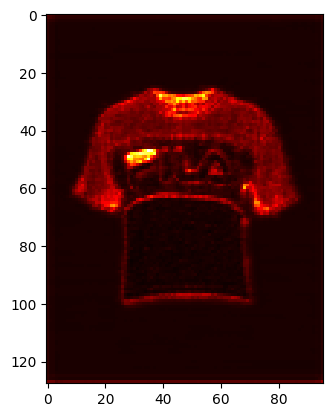

In [65]:
q_inx = 5321 # F character
x3 = (attention_map_hd[1,q_inx,:,:])
attn_map_view_norm = (x3 - x3.min()) / (x3.max() - x3.min())
# torchvision.transforms.ToPILImage()(attn_map_view_norm)
plt.imshow(attn_map_view_norm.cpu().numpy(), cmap='hot', interpolation='nearest')
plt.show()

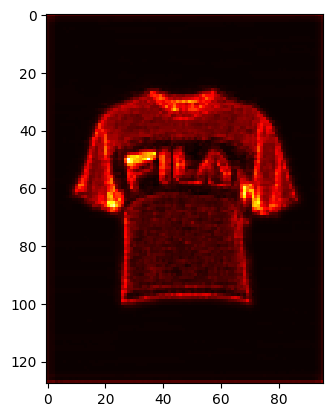

In [66]:
q_inx = 5511 # F character
x3 = (attention_map_hd[1,q_inx,:,:])
attn_map_view_norm = (x3 - x3.min()) / (x3.max() - x3.min())
# torchvision.transforms.ToPILImage()(attn_map_view_norm)
plt.imshow(attn_map_view_norm.cpu().numpy(), cmap='hot', interpolation='nearest')
plt.show()

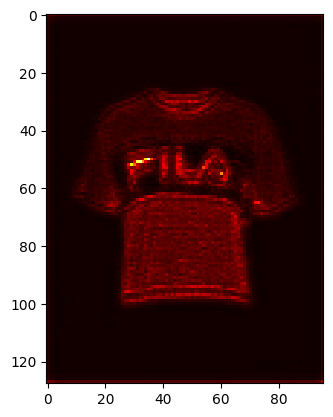

In [67]:
q_inx = 5514 # F character
x3 = (attention_map_hd[1,q_inx,:,:])
attn_map_view_norm = (x3 - x3.min()) / (x3.max() - x3.min())
# torchvision.transforms.ToPILImage()(attn_map_view_norm)
plt.imshow(attn_map_view_norm.cpu().numpy(), cmap='hot', interpolation='nearest')
plt.show()

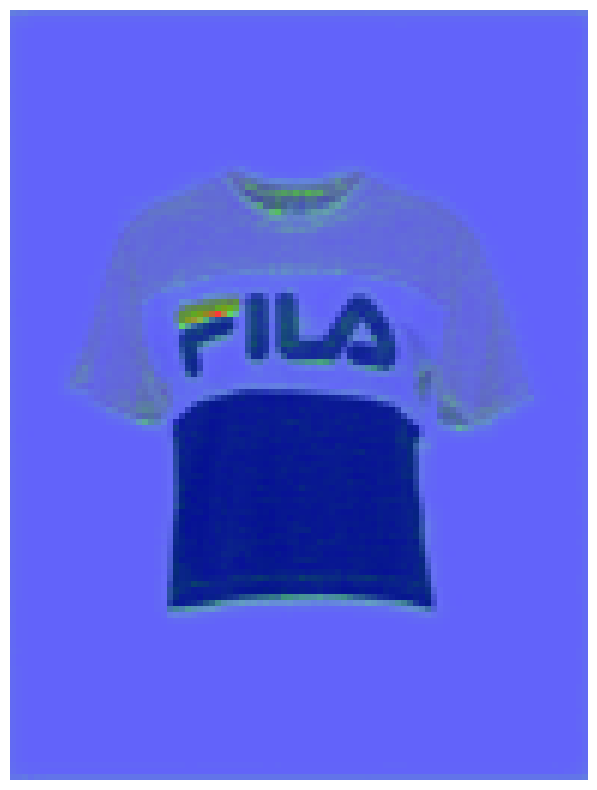

array([[[[0.        , 0.18039216, 0.81960784]],

        [[0.        , 0.14901961, 0.85098039]],

        [[0.        , 0.16470588, 0.83529412]],

        ...,

        [[0.        , 0.13333333, 0.86666667]],

        [[0.        , 0.15686275, 0.84313725]],

        [[0.        , 0.15686275, 0.84313725]]],


       [[[0.        , 0.07843137, 0.92156863]],

        [[0.        , 0.0627451 , 0.9372549 ]],

        [[0.        , 0.05490196, 0.94509804]],

        ...,

        [[0.        , 0.03921569, 0.96078431]],

        [[0.        , 0.04705882, 0.95294118]],

        [[0.        , 0.07843137, 0.92156863]]],


       [[[0.        , 0.0627451 , 0.9372549 ]],

        [[0.        , 0.03921569, 0.96078431]],

        [[0.        , 0.03921569, 0.96078431]],

        ...,

        [[0.        , 0.02352941, 0.97647059]],

        [[0.        , 0.03137255, 0.96862745]],

        [[0.        , 0.0627451 , 0.9372549 ]]],


       ...,


       [[[0.        , 0.0627451 , 0.9372549 ]],

       

In [94]:
q_inx = 5421 # F character
x3 = (attention_map_hd[1,q_inx,:,:])
attn_map_view_norm = (x3 - x3.min()) / (x3.max() - x3.min())
# torchvision.transforms.ToPILImage()(attn_map_view_norm)
# plt.imshow(attn_map_view_norm.cpu().numpy(), cmap='hot', interpolation='nearest')
# plt.show()
visualize_attention_rgb(x3,128,96,overlay_image=overlay_image, alpha=0.6, save_path=None)

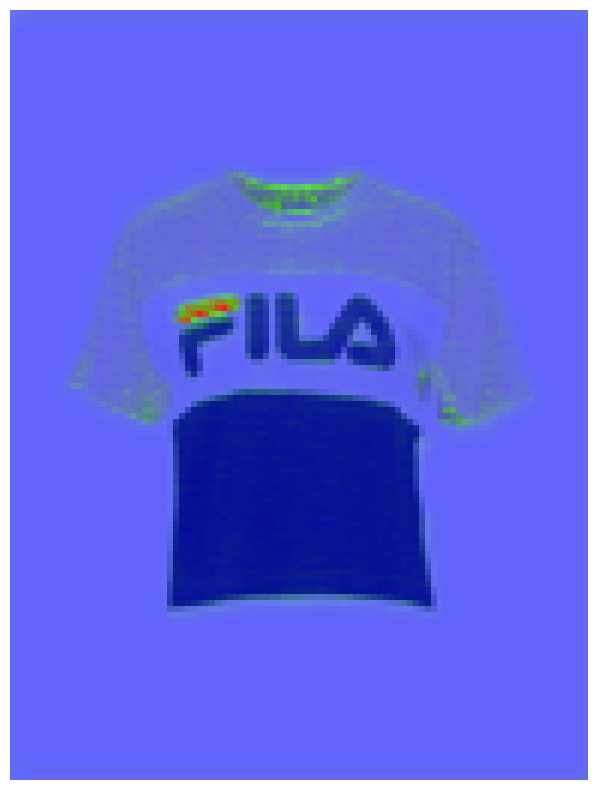

array([[[[0.        , 0.1254902 , 0.8745098 ]],

        [[0.        , 0.07843137, 0.92156863]],

        [[0.        , 0.07843137, 0.92156863]],

        ...,

        [[0.        , 0.0627451 , 0.9372549 ]],

        [[0.        , 0.0627451 , 0.9372549 ]],

        [[0.        , 0.07058824, 0.92941176]]],


       [[[0.        , 0.08627451, 0.91372549]],

        [[0.        , 0.05490196, 0.94509804]],

        [[0.        , 0.05490196, 0.94509804]],

        ...,

        [[0.        , 0.03921569, 0.96078431]],

        [[0.        , 0.03921569, 0.96078431]],

        [[0.        , 0.0627451 , 0.9372549 ]]],


       [[[0.        , 0.07058824, 0.92941176]],

        [[0.        , 0.03921569, 0.96078431]],

        [[0.        , 0.03921569, 0.96078431]],

        ...,

        [[0.        , 0.02352941, 0.97647059]],

        [[0.        , 0.02352941, 0.97647059]],

        [[0.        , 0.04705882, 0.95294118]]],


       ...,


       [[[0.        , 0.0627451 , 0.9372549 ]],

       

In [ ]:
q_inx = 5417 # F character
x3 = (attention_map_hd[1,q_inx,:,:])
attn_map_view_norm = (x3 - x3.min()) / (x3.max() - x3.min())
# torchvision.transforms.ToPILImage()(attn_map_view_norm)
# plt.imshow(attn_map_view_norm.cpu().numpy(), cmap='hot', interpolation='nearest')
# plt.show()
visualize_attention_rgb(x3,128,96,overlay_image=overlay_image, alpha=0.6, save_path=None)

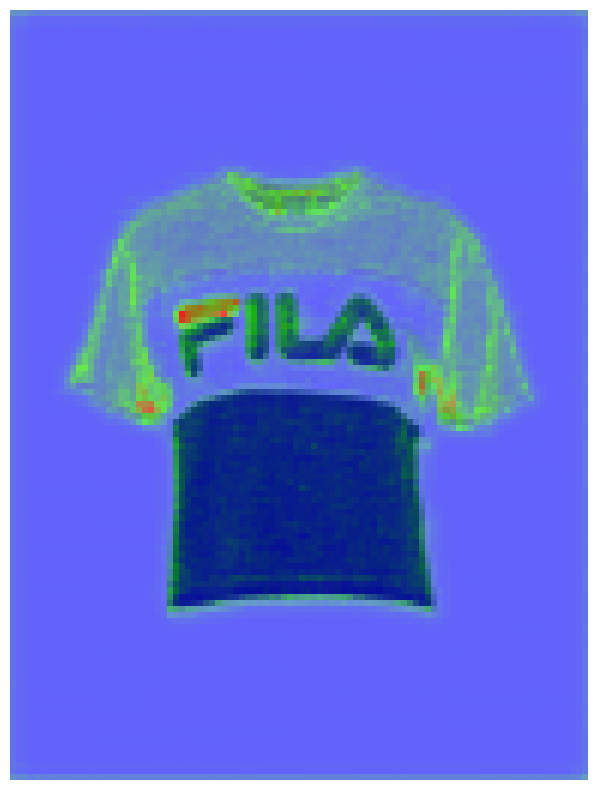

array([[[[0.        , 0.3372549 , 0.6627451 ]],

        [[0.        , 0.28235294, 0.71764706]],

        [[0.        , 0.29803922, 0.70196078]],

        ...,

        [[0.        , 0.23529412, 0.76470588]],

        [[0.        , 0.28235294, 0.71764706]],

        [[0.        , 0.30588235, 0.69411765]]],


       [[[0.        , 0.14901961, 0.85098039]],

        [[0.        , 0.11764706, 0.88235294]],

        [[0.        , 0.10196078, 0.89803922]],

        ...,

        [[0.        , 0.0627451 , 0.9372549 ]],

        [[0.        , 0.08627451, 0.91372549]],

        [[0.        , 0.16470588, 0.83529412]]],


       [[[0.        , 0.11764706, 0.88235294]],

        [[0.        , 0.08627451, 0.91372549]],

        [[0.        , 0.07843137, 0.92156863]],

        ...,

        [[0.        , 0.04705882, 0.95294118]],

        [[0.        , 0.0627451 , 0.9372549 ]],

        [[0.        , 0.14117647, 0.85882353]]],


       ...,


       [[[0.        , 0.11764706, 0.88235294]],

       

In [96]:
q_inx = 5511 # F character
x3 = (attention_map_hd[1,q_inx,:,:])
attn_map_view_norm = (x3 - x3.min()) / (x3.max() - x3.min())
# torchvision.transforms.ToPILImage()(attn_map_view_norm)
# plt.imshow(attn_map_view_norm.cpu().numpy(), cmap='hot', interpolation='nearest')
# plt.show()
visualize_attention_rgb(x3,128,96,overlay_image=overlay_image, alpha=0.6, save_path=None)

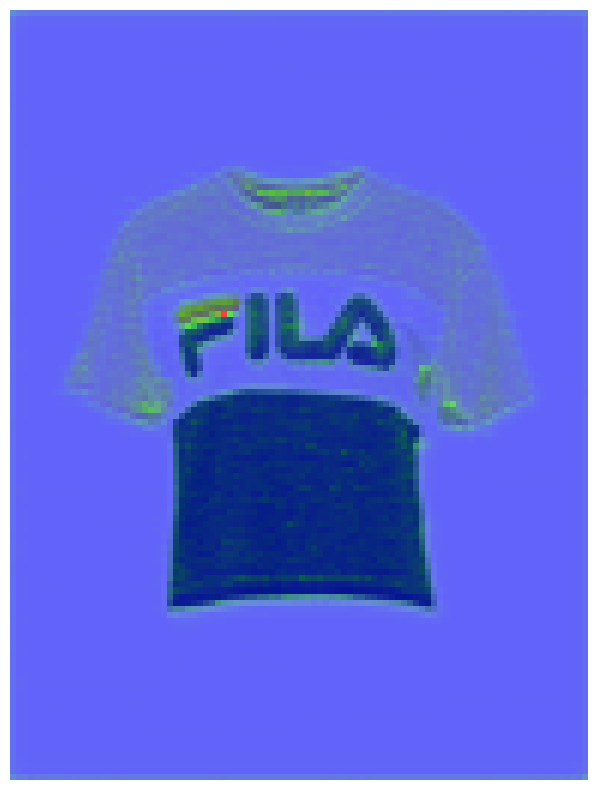

array([[[[0.        , 0.29019608, 0.70980392]],

        [[0.        , 0.19607843, 0.80392157]],

        [[0.        , 0.17254902, 0.82745098]],

        ...,

        [[0.        , 0.15686275, 0.84313725]],

        [[0.        , 0.16470588, 0.83529412]],

        [[0.        , 0.18823529, 0.81176471]]],


       [[[0.        , 0.13333333, 0.86666667]],

        [[0.        , 0.05490196, 0.94509804]],

        [[0.        , 0.04705882, 0.95294118]],

        ...,

        [[0.        , 0.03137255, 0.96862745]],

        [[0.        , 0.03137255, 0.96862745]],

        [[0.        , 0.07843137, 0.92156863]]],


       [[[0.        , 0.10196078, 0.89803922]],

        [[0.        , 0.03921569, 0.96078431]],

        [[0.        , 0.03921569, 0.96078431]],

        ...,

        [[0.        , 0.02352941, 0.97647059]],

        [[0.        , 0.02352941, 0.97647059]],

        [[0.        , 0.07843137, 0.92156863]]],


       ...,


       [[[0.        , 0.09411765, 0.90588235]],

       

In [97]:
q_inx = 5512 # F character
x3 = (attention_map_hd[1,q_inx,:,:])
attn_map_view_norm = (x3 - x3.min()) / (x3.max() - x3.min())
# torchvision.transforms.ToPILImage()(attn_map_view_norm)
# plt.imshow(attn_map_view_norm.cpu().numpy(), cmap='hot', interpolation='nearest')
# plt.show()
visualize_attention_rgb(x3,128,96,overlay_image=overlay_image, alpha=0.6, save_path=None)

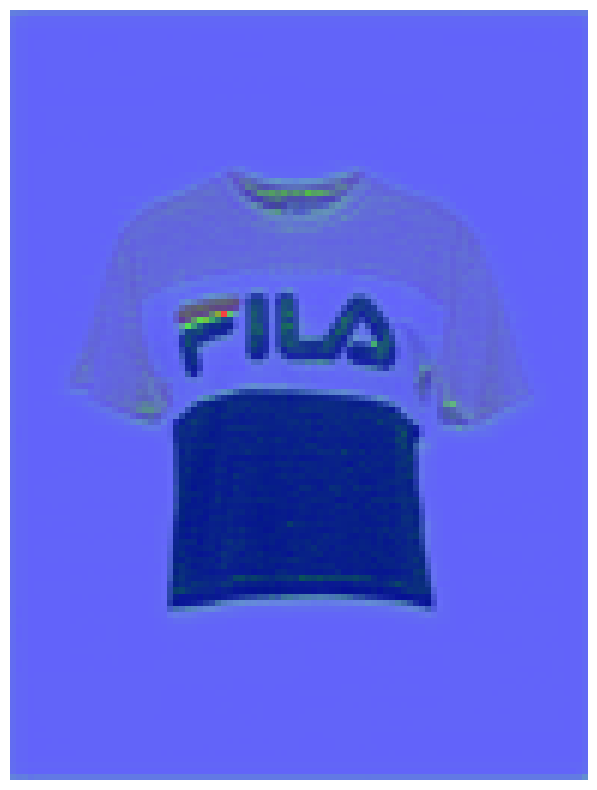

array([[[[0.        , 0.18823529, 0.81176471]],

        [[0.        , 0.17254902, 0.82745098]],

        [[0.        , 0.16470588, 0.83529412]],

        ...,

        [[0.        , 0.14117647, 0.85882353]],

        [[0.        , 0.14901961, 0.85098039]],

        [[0.        , 0.16470588, 0.83529412]]],


       [[[0.        , 0.09411765, 0.90588235]],

        [[0.        , 0.05490196, 0.94509804]],

        [[0.        , 0.04705882, 0.95294118]],

        ...,

        [[0.        , 0.03137255, 0.96862745]],

        [[0.        , 0.03921569, 0.96078431]],

        [[0.        , 0.07058824, 0.92941176]]],


       [[[0.        , 0.07843137, 0.92156863]],

        [[0.        , 0.03921569, 0.96078431]],

        [[0.        , 0.04705882, 0.95294118]],

        ...,

        [[0.        , 0.03137255, 0.96862745]],

        [[0.        , 0.03137255, 0.96862745]],

        [[0.        , 0.0627451 , 0.9372549 ]]],


       ...,


       [[[0.        , 0.07058824, 0.92941176]],

       

In [98]:
q_inx = 5513 # F character
x3 = (attention_map_hd[1,q_inx,:,:])
attn_map_view_norm = (x3 - x3.min()) / (x3.max() - x3.min())
# torchvision.transforms.ToPILImage()(attn_map_view_norm)
# plt.imshow(attn_map_view_norm.cpu().numpy(), cmap='hot', interpolation='nearest')
# plt.show()
visualize_attention_rgb(x3,128,96,overlay_image=overlay_image, alpha=0.6, save_path=None)

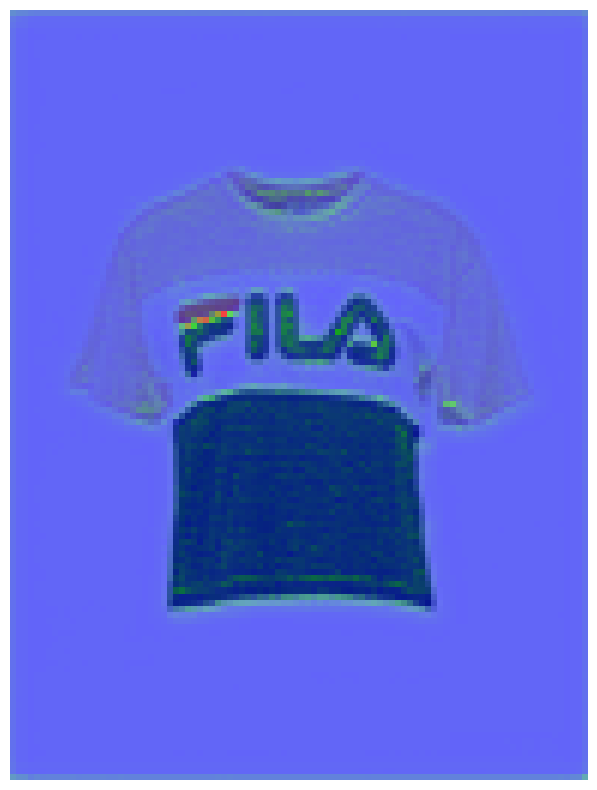

array([[[[0.        , 0.28235294, 0.71764706]],

        [[0.        , 0.23529412, 0.76470588]],

        [[0.        , 0.22745098, 0.77254902]],

        ...,

        [[0.        , 0.20392157, 0.79607843]],

        [[0.        , 0.20392157, 0.79607843]],

        [[0.        , 0.25882353, 0.74117647]]],


       [[[0.        , 0.14117647, 0.85882353]],

        [[0.        , 0.09411765, 0.90588235]],

        [[0.        , 0.07843137, 0.92156863]],

        ...,

        [[0.        , 0.05490196, 0.94509804]],

        [[0.        , 0.0627451 , 0.9372549 ]],

        [[0.        , 0.1254902 , 0.8745098 ]]],


       [[[0.        , 0.11764706, 0.88235294]],

        [[0.        , 0.07058824, 0.92941176]],

        [[0.        , 0.07058824, 0.92941176]],

        ...,

        [[0.        , 0.04705882, 0.95294118]],

        [[0.        , 0.04705882, 0.95294118]],

        [[0.        , 0.11764706, 0.88235294]]],


       ...,


       [[[0.        , 0.11764706, 0.88235294]],

       

In [99]:
q_inx = 5514 # F character
x3 = (attention_map_hd[1,q_inx,:,:])
attn_map_view_norm = (x3 - x3.min()) / (x3.max() - x3.min())
# torchvision.transforms.ToPILImage()(attn_map_view_norm)
# plt.imshow(attn_map_view_norm.cpu().numpy(), cmap='hot', interpolation='nearest')
# plt.show()
visualize_attention_rgb(x3,128,96,overlay_image=overlay_image, alpha=0.6, save_path=None)

In [ ]:
q_inx = 5516 # F character
x3 = (attention_map_hd[1,q_inx,:,:])
attn_map_view_norm = (x3 - x3.min()) / (x3.max() - x3.min())
# torchvision.transforms.ToPILImage()(attn_map_view_norm)
# plt.imshow(attn_map_view_norm.cpu().numpy(), cmap='hot', interpolation='nearest')
# plt.show()
visualize_attention_rgb(x3,128,96,overlay_image=overlay_image, alpha=0.6, save_path=None)

In [ ]:
q_inx = 5417 # F character
x3 = (attention_map_hd[1,q_inx,:,:])
attn_map_view_norm = (x3 - x3.min()) / (x3.max() - x3.min())
# torchvision.transforms.ToPILImage()(attn_map_view_norm)
# plt.imshow(attn_map_view_norm.cpu().numpy(), cmap='hot', interpolation='nearest')
# plt.show()
visualize_attention_rgb(x3,128,96,overlay_image=overlay_image, alpha=0.6, save_path=None)

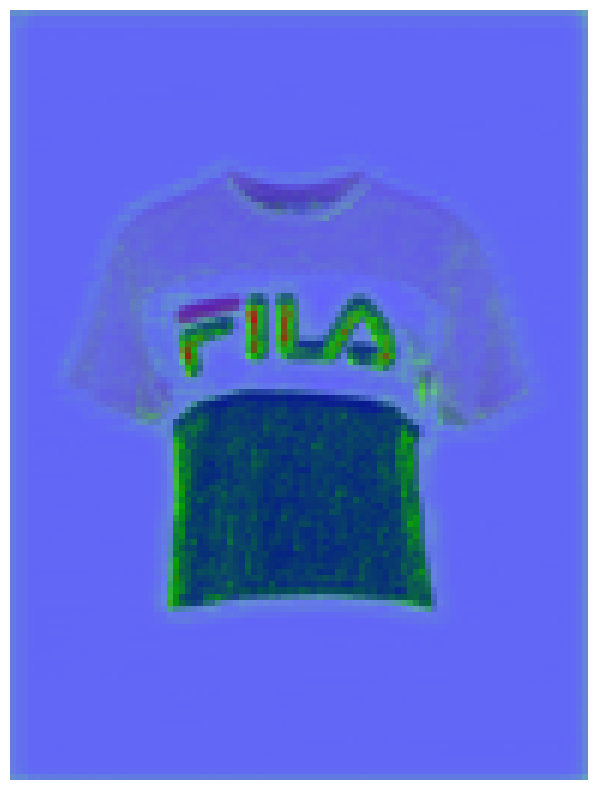

array([[[[0.        , 0.28235294, 0.71764706]],

        [[0.        , 0.2745098 , 0.7254902 ]],

        [[0.        , 0.29803922, 0.70196078]],

        ...,

        [[0.        , 0.22745098, 0.77254902]],

        [[0.        , 0.31372549, 0.68627451]],

        [[0.        , 0.41568627, 0.58431373]]],


       [[[0.        , 0.16470588, 0.83529412]],

        [[0.        , 0.16470588, 0.83529412]],

        [[0.        , 0.14901961, 0.85098039]],

        ...,

        [[0.        , 0.08627451, 0.91372549]],

        [[0.        , 0.14901961, 0.85098039]],

        [[0.        , 0.29803922, 0.70196078]]],


       [[[0.        , 0.18039216, 0.81960784]],

        [[0.        , 0.16470588, 0.83529412]],

        [[0.        , 0.13333333, 0.86666667]],

        ...,

        [[0.        , 0.08627451, 0.91372549]],

        [[0.        , 0.14117647, 0.85882353]],

        [[0.        , 0.28235294, 0.71764706]]],


       ...,


       [[[0.        , 0.17254902, 0.82745098]],

       

In [87]:
q_inx = 5520 # I charater
x3 = (attention_map_hd[1,q_inx,:,:])
attn_map_view_norm = (x3 - x3.min()) / (x3.max() - x3.min())
# torchvision.transforms.ToPILImage()(attn_map_view_norm)
# plt.imshow(attn_map_view_norm.cpu().numpy(), cmap='hot', interpolation='nearest')
# plt.show()
visualize_attention_rgb(x3,128,96,overlay_image=overlay_image, alpha=0.6, save_path=None)

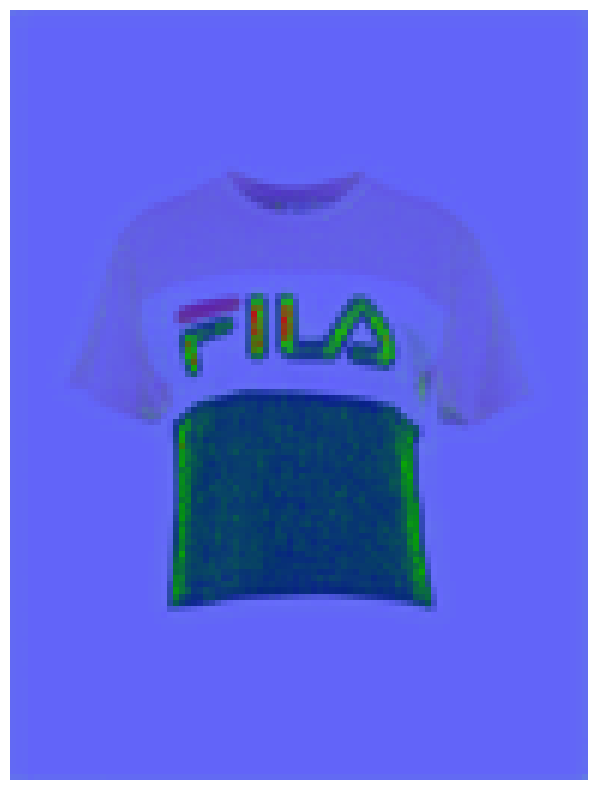

array([[[[0.        , 0.10196078, 0.89803922]],

        [[0.        , 0.07058824, 0.92941176]],

        [[0.        , 0.08627451, 0.91372549]],

        ...,

        [[0.        , 0.0627451 , 0.9372549 ]],

        [[0.        , 0.07843137, 0.92156863]],

        [[0.        , 0.09411765, 0.90588235]]],


       [[[0.        , 0.04705882, 0.95294118]],

        [[0.        , 0.05490196, 0.94509804]],

        [[0.        , 0.05490196, 0.94509804]],

        ...,

        [[0.        , 0.03921569, 0.96078431]],

        [[0.        , 0.05490196, 0.94509804]],

        [[0.        , 0.07843137, 0.92156863]]],


       [[[0.        , 0.05490196, 0.94509804]],

        [[0.        , 0.05490196, 0.94509804]],

        [[0.        , 0.05490196, 0.94509804]],

        ...,

        [[0.        , 0.03137255, 0.96862745]],

        [[0.        , 0.05490196, 0.94509804]],

        [[0.        , 0.07058824, 0.92941176]]],


       ...,


       [[[0.        , 0.04705882, 0.95294118]],

       

In [88]:
q_inx = 5621 # L charater
x3 = (attention_map_hd[1,q_inx,:,:])
attn_map_view_norm = (x3 - x3.min()) / (x3.max() - x3.min())
# torchvision.transforms.ToPILImage()(attn_map_view_norm)
# plt.imshow(attn_map_view_norm.cpu().numpy(), cmap='hot', interpolation='nearest')
# plt.show()
visualize_attention_rgb(x3,128,96,overlay_image=overlay_image, alpha=0.6, save_path=None)

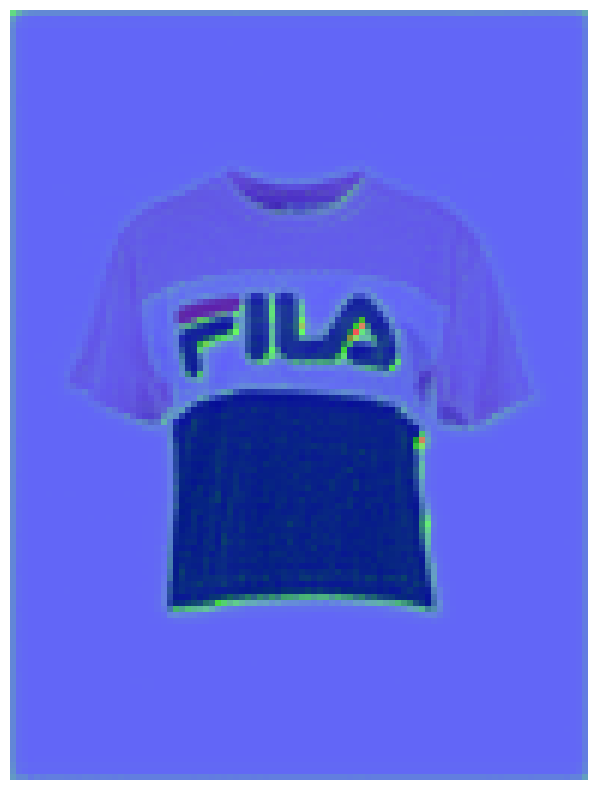

array([[[[0.        , 0.79215686, 0.20784314]],

        [[0.        , 0.50196078, 0.49803922]],

        [[0.        , 0.32156863, 0.67843137]],

        ...,

        [[0.        , 0.2745098 , 0.7254902 ]],

        [[0.        , 0.32156863, 0.67843137]],

        [[0.        , 0.45490196, 0.54509804]]],


       [[[0.        , 0.35294118, 0.64705882]],

        [[0.        , 0.1254902 , 0.8745098 ]],

        [[0.        , 0.0627451 , 0.9372549 ]],

        ...,

        [[0.        , 0.04705882, 0.95294118]],

        [[0.        , 0.07058824, 0.92941176]],

        [[0.        , 0.21176471, 0.78823529]]],


       [[[0.        , 0.26666667, 0.73333333]],

        [[0.        , 0.08627451, 0.91372549]],

        [[0.        , 0.0627451 , 0.9372549 ]],

        ...,

        [[0.        , 0.05490196, 0.94509804]],

        [[0.        , 0.07058824, 0.92941176]],

        [[0.        , 0.20392157, 0.79607843]]],


       ...,


       [[[0.        , 0.2745098 , 0.7254902 ]],

       

In [90]:
q_inx = 5823 # A charater
x3 = (attention_map_hd[1,q_inx,:,:])
attn_map_view_norm = (x3 - x3.min()) / (x3.max() - x3.min())
# torchvision.transforms.ToPILImage()(attn_map_view_norm)
# plt.imshow(attn_map_view_norm.cpu().numpy(), cmap='hot', interpolation='nearest')
# plt.show()
visualize_attention_rgb(x3,128,96,overlay_image=overlay_image, alpha=0.6, save_path=None)

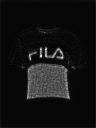

In [51]:
q_inx = 3893 # Neck region
x3 = (attention_map_hd[1,q_inx,:,:])
attn_map_view_norm = (x3 - x3.min()) / (x3.max() - x3.min())
torchvision.transforms.ToPILImage()(attn_map_view_norm)

# Test 

In [33]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
import torch
import torch.nn.functional as F
from einops import rearrange
from PIL import Image
import torchvision


In [ ]:
attention_map_hd = torch.load("attention_map_hd.pt")

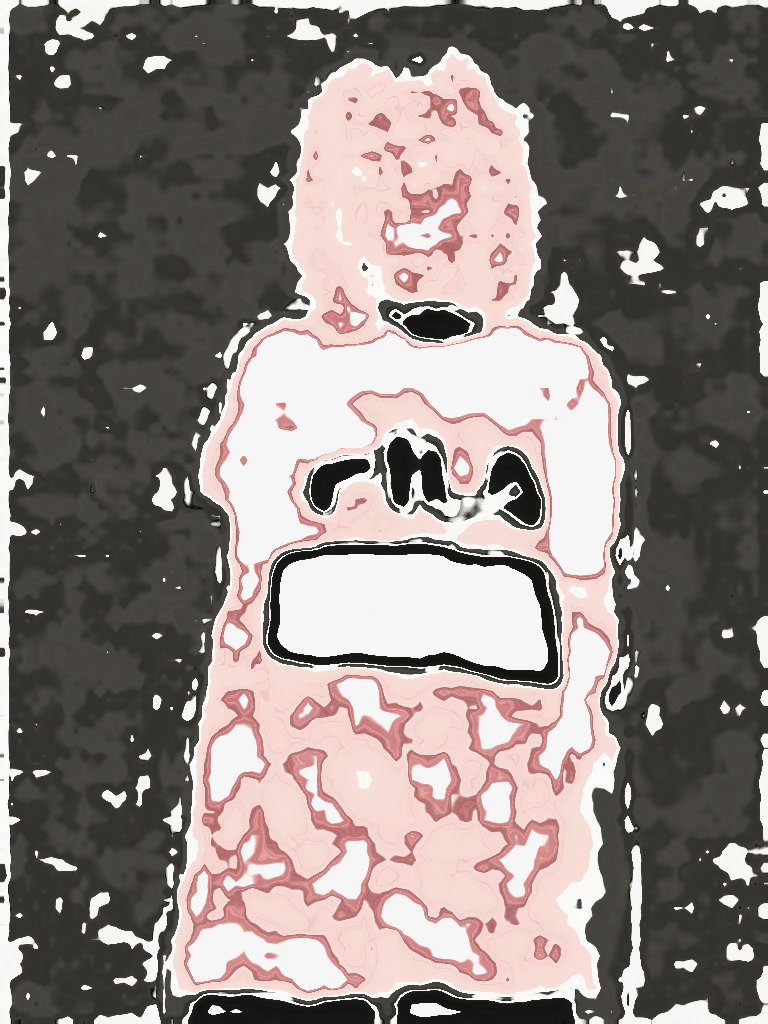

In [73]:
H,W= 128,96
A = attention_map_hd.view(attention_map_hd.size(0), attention_map_hd.size(1), -1)
# A_norm=(A-torch.min(A, dim=-1,keepdim=True)[0]) / (torch.max(A, dim=-1,keepdim=True)[0] - torch.min(A, dim=-1,keepdim=True)[0])
# A_norm=(A-torch.min(A, dim=-1,keepdim=True)[0]) / torch.max(A, dim=-1,keepdim=True)[0]
A_norm =A
# A_norm = A_norm.cuda()
y_coords, x_coords = torch.meshgrid(
    torch.linspace(-1, 1, H, device='cuda'),
    torch.linspace(-1, 1, W, device='cuda'),
    indexing='ij'
)
coords = torch.stack([x_coords, y_coords], dim=-1)  # (H, W, 2)
coords = coords.view(1, H * W, 2)  # Reshape to (1, H*W, 2)
F_l = torch.matmul(A_norm, coords.to(A.dtype))
F_l = rearrange(F_l, 'b (h w) d -> b h w d',h=128)
F_l = F_l.permute(0, 3, 1, 2)  # (B, 2, h, w)
F_l_up = F.interpolate(F_l, size=(1024, 768), mode='bilinear', align_corners=False)
F_l_up = F_l_up.permute(0, 2, 3, 1)  # Back to (B, H, W, 2)
ref_img_pil = Image.open("/workspace/Try-on-Product/projects/Leffa/01486_00.jpg").resize((768,1024))
ref_img_tensor = torchvision.transforms.ToTensor()(ref_img_pil).unsqueeze(0).to('cuda')
# ref_img_tensor = ref_img_tensor*2-1
ref_img_tensor = ref_img_tensor.repeat(2, 1, 1, 1)
warped_grid_norm = (F_l_up - F_l_up.min()) / (F_l_up.max()-F_l_up.min()) * 2 - 1  # [-1, 1]
# warped_grid_norm = (F_l_up - F_l_up.min()) / (F_l_up.max()) * 2 - 1  # [-1, 1]
warped_image_1 = F.grid_sample(ref_img_tensor[0].unsqueeze(0).float(), warped_grid_norm[1].unsqueeze(0).float(),
                                    mode='bilinear', padding_mode='border', align_corners=True)
warped_image_1_pil = torchvision.transforms.ToPILImage()(warped_image_1[0].cpu())
warped_image_1_pil

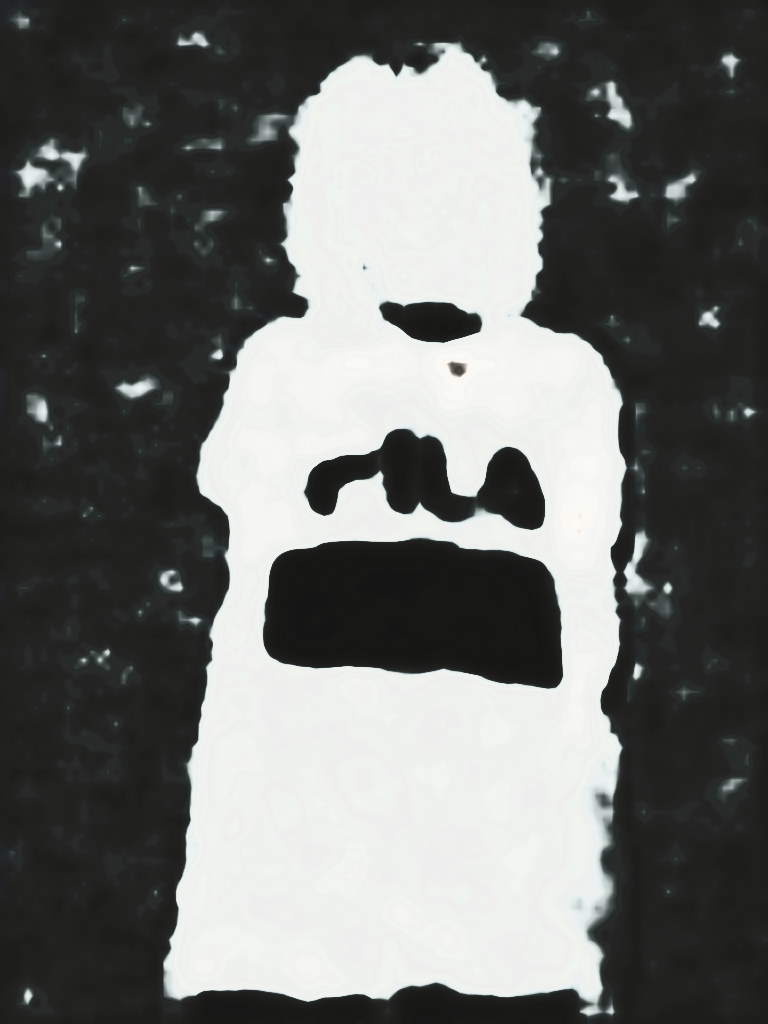

In [74]:
warped_grid_norm = F_l_up
# warped_grid_norm = (F_l_up - F_l_up.min()) / (F_l_up.max()) * 2 - 1  # [-1, 1]
warped_image_1 = F.grid_sample(ref_img_tensor[0].unsqueeze(0).float(), warped_grid_norm[1].unsqueeze(0).float(),
                                    mode='bilinear', padding_mode='border', align_corners=True)
warped_image_1_pil = torchvision.transforms.ToPILImage()(warped_image_1[0].cpu())
warped_image_1_pil

In [84]:
from scipy.ndimage import zoom
import cv2
import numpy as np

In [76]:
scale_factors = (1024 / 128, 768 / 96, 1)

In [77]:
fl_loaded= F_l.cpu().numpy()

In [78]:
fl_loaded.shape

(2, 2, 128, 96)

In [81]:
fl_loaded[1].shape

(2, 128, 96)

In [82]:
fl_loaded = fl_loaded[1].transpose(1,2,0)

In [85]:
fl_up = zoom(fl_loaded.astype(np.float32), scale_factors, order=1)  # (1024, 768, 2)
fl_up = (fl_up - fl_up.min()) / (fl_up.max() - fl_up.min()) * 2 - 1  # [-1, 1]
fl_up_tensor = torch.tensor(fl_up, dtype=torch.float32).unsqueeze(0)  # (1, 1024, 768, 2)

# Load image
image = cv2.imread("/workspace/Try-on-Product/projects/Leffa/01486_00.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image_tensor = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0) / 255  # [1, 3, 1024, 768], [0, 1]
image_tensor = image_tensor * 2 - 1  # [-1, 1]

# Check shape
print("Image shape:", image_tensor.shape)  # [1, 3, 1024, 768]
print("Flow shape:", fl_up_tensor.shape)  # [1, 1024, 768, 2]

# Apply grid_sample
warped_image = F.grid_sample(image_tensor, fl_up_tensor, mode="nearest", padding_mode="border", align_corners=True)

warped_image_np = warped_image.squeeze(0).permute(1, 2, 0).cpu().numpy()  # [1024, 768, 3]
warped_image_np = (warped_image_np + 1) / 2  # [-1, 1] -> [0, 1]
warped_image_np = (warped_image_np * 255).clip(0, 255).astype(np.uint8)  # [0, 255]

cv2.imwrite("warped_image.png", cv2.cvtColor(warped_image_np, cv2.COLOR_RGB2BGR))

# Kiểm tra
print("Warped min/max:", warped_image_np.min(), warped_image_np.max())

Image shape: torch.Size([1, 3, 1024, 768])
Flow shape: torch.Size([1, 1024, 768, 2])
Warped min/max: 5 255
